In [13]:
import json
from collections import Counter, defaultdict
from typing import Dict, List, Any
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set up plotting
%matplotlib inline
plt.style.use('seaborn-v0_8-notebook')

## Load and Prepare Data

In [14]:
def load_json_data(file_path: str) -> List[Dict[str, Any]]:
    with open(file_path, 'r') as file:
        return json.load(file)

# Load the data
data = load_json_data('/home/manishs/buckets/pyperf_bucket/testgen/pylint_out.json')
print(f"Loaded {len(data)} items from the JSON file.")

Loaded 2154 items from the JSON file.


## Define Helper Functions

In [15]:
def get_test_status(item):
    if item["test_history"]["history"][0]["exec_stats"].get("error"):
        return "error"

    # if tests ran
    elif item["test_history"]["history"][0]["exec_stats"]["run_tests_logs"].get("test_0"):
        # if at least one test passed
        if item["test_history"]["history"][0]["exec_stats"]["run_tests_logs"]["test_0"]["passed_count"] > 0:
            return "success"
        # some tests ran but failed/errored
        else:
            return "failure"
    # tests did not run
    else:
        return "error"

def extract_error_details(error_message: str) -> Dict[str, str]:
    file_line_match = re.search(r'File "(.*?)", line (\d+)', error_message)
    # find the last match for file and line number, NOT THE FIRST
    file_line_match = re.findall(r'File "(.*?)", line (\d+)', error_message)
    file_path = file_line_match[-1][0] if file_line_match else "Unknown"
    line_number = file_line_match[-1][1] if file_line_match else "Unknown"

    error_type_match = re.search(r'([A-Za-z]+(Error|Warning)|WARNING):', error_message, re.MULTILINE)
    error_type = error_type_match.group(1) if error_type_match else "Unknown"
    
    error_desc_match = re.search(r'([A-Za-z]+(Error|Warning)|WARNING):(.+)$', error_message, re.MULTILINE)
    error_description = error_desc_match.group(3).strip() if error_desc_match else "Unknown"
    error_description = error_type + ": " + error_description
    
    # print(error_message)
    # print("File Path:", file_path)
    # print("Line Number:", line_number)
    # print("Error Type:", error_type)
    # print("Error Description:", error_description)
    # print("=="*20)
    # print()

    return {
        "file_path": file_path,
        "line_number": line_number,
        "error_type": error_type,
        "error_description": error_description
    }

## Analyze Results

In [16]:
def analyze_results(data: List[Dict[str, Any]]) -> Dict[str, Any]:
    total_functions = 0
    status_counts = Counter()
    ids = {"success": [], "error": [], "failure": [], "test": [], 'invalid': []}
    error_types = Counter()
    error_locations = Counter()
    error_descriptions = Counter()
    failure_types = Counter()
    failure_locations = Counter()
    failure_descriptions = Counter()

    for item in data:
        fid = item.get("function_id", item.get("method_id", {})).get("identifier", "")
    
        total_functions += 1
        status = get_test_status(item)
        status_counts[status] += 1
        test_history = item['test_history']['history'][0]
        exec_stats = test_history['exec_stats']
        
        if not item.get('function_code', item.get('method_code', None)):
            ids['invalid'].append(fid)
            print(f"Invalid function: {fid}")
            
        if not test_history.get('tests').get('test_0', None):
            ids['invalid'].append(fid)
            print(f"Invalid test: {fid}")

        if 'test' in fid.lower():
            # print("Test function:", fid)
            ids["test"].append(fid)

        if status == "error":
            ids["error"].append(fid)
            error_message = exec_stats.get('error', '')
            
            if error_message:
                error_details = extract_error_details(error_message)
                error_types[error_details['error_type']] += 1
                error_locations[error_details['file_path']] += 1
                error_descriptions[error_details['error_description']] += 1
        
        elif status == "failure":
            ids["failure"].append(fid)
            try:
                failure_message = exec_stats.get('run_test_errors', {}).get('test_0', [{}])[0].get('message', '')
            except:
                failure_message = None
                pass
            
            if failure_message:
                failure_details = extract_error_details(failure_message)
                failure_types[failure_details['error_type']] += 1
                failure_locations[failure_details['file_path']] += 1
                failure_descriptions[failure_details['error_description']] += 1
        
        else:
            ids["success"].append(fid)

    return {
        'ids': ids,
        'total_functions': total_functions,
        'status_counts': dict(status_counts),
        'error_types': dict(error_types),
        'error_locations': dict(error_locations),
        'error_descriptions': dict(error_descriptions),
        'failure_types': dict(failure_types),
        'failure_locations': dict(failure_locations),
        'failure_descriptions': dict(failure_descriptions)
    }

analysis_results = analyze_results(data)
print("Analysis complete.")

Invalid test: pylint.utils.linterstats.LinterStats.__repr__
Invalid test: pylint.config.config_file_parser._ConfigurationFileParser.parse_config_file
Analysis complete.


## Visualize Results

Test Counts: {'success': 3, 'failure': 4, 'error': 5}
Non-Test Counts: {'success': 578, 'failure': 463, 'error': 1099}


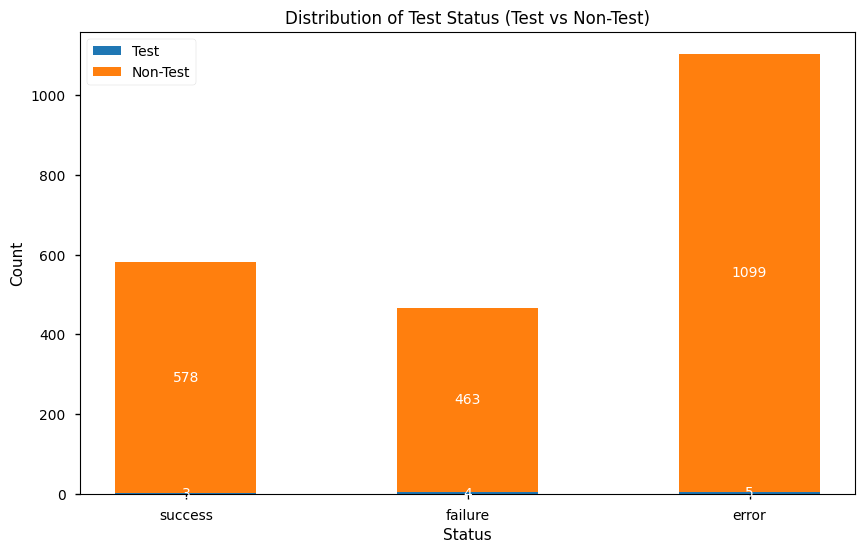

In [17]:
def plot_status_distribution(status_counts: Dict[str, int], ids: Dict[str, List[str]]):
    test_counts = {status: 0 for status in status_counts.keys()}
    non_test_counts = {status: 0 for status in status_counts.keys()}
    
    test_ids = ids.get('test', [])
    invalid_ids = ids.get('invalid', [])
    temp_ids = ids.copy()
    temp_ids.pop('test')
    temp_ids.pop('invalid')
    
    for status, id_list in temp_ids.items():
        for fid in id_list:
            if fid in test_ids:
                test_counts[status] += 1
            elif fid in invalid_ids:
                continue
            else:
                non_test_counts[status] += 1
                
    print("Test Counts:", test_counts)
    print("Non-Test Counts:", non_test_counts)
    
    labels = list(status_counts.keys())
    test_values = [test_counts[status] for status in labels]
    non_test_values = [non_test_counts[status] for status in labels]
    
    plt.figure(figsize=(10, 6))
    bar_width = 0.5
    bar1 = plt.bar(labels, test_values, bar_width, label='Test')
    bar2 = plt.bar(labels, non_test_values, bar_width, bottom=test_values, label='Non-Test')
    
    for i, (test_count, non_test_count) in enumerate(zip(test_values, non_test_values)):
        plt.text(i, test_count / 2, str(test_count), ha='center', va='center', color='white')
        plt.text(i, test_count + non_test_count / 2, str(non_test_count), ha='center', va='center', color='white')
    
    plt.title('Distribution of Test Status (Test vs Non-Test)')
    plt.xlabel('Status')
    plt.ylabel('Count')
    plt.legend()
    plt.show()

plot_status_distribution(analysis_results['status_counts'], analysis_results['ids'])

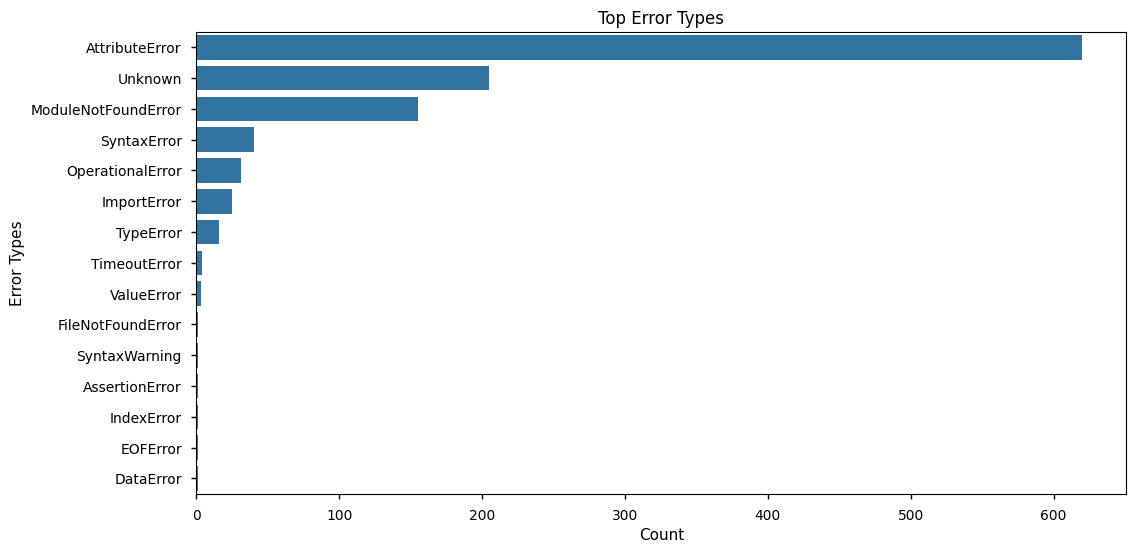

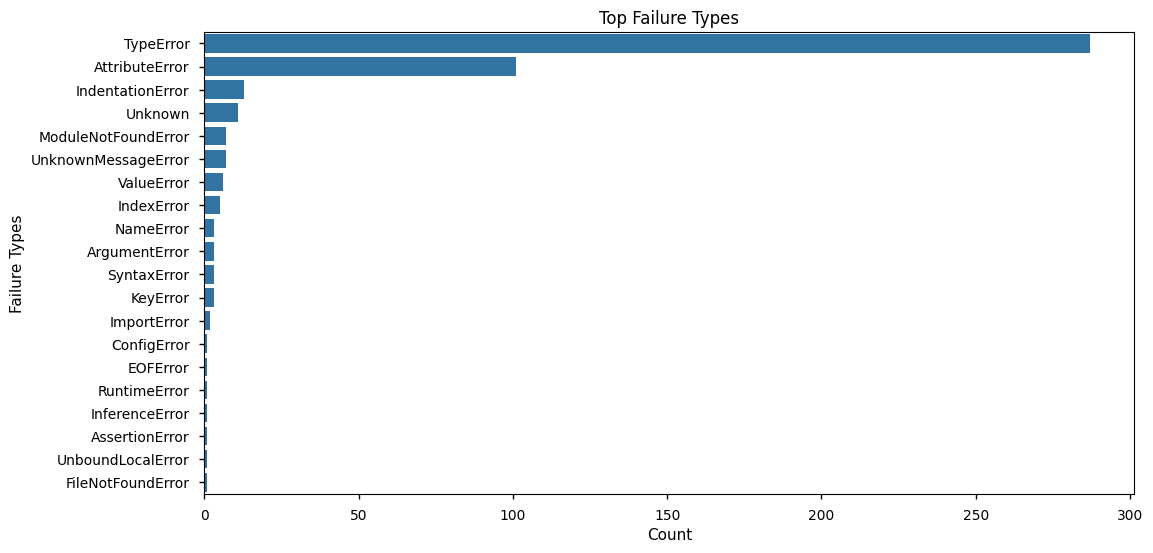

In [18]:
def plot_top(error_dict: Dict[str, int], title: str, n: int = 10):
    top_n = dict(sorted(error_dict.items(), key=lambda x: x[1], reverse=True)[:n])
    plt.figure(figsize=(12, 6))
    sns.barplot(x=list(top_n.values()), y=list(top_n.keys()))
    plt.title(f'Top {title}')
    plt.xlabel('Count')
    plt.ylabel(title)
    plt.show()

plot_top(analysis_results['error_types'], 'Error Types', n=20)
plot_top(analysis_results['failure_types'], 'Failure Types', n=20)


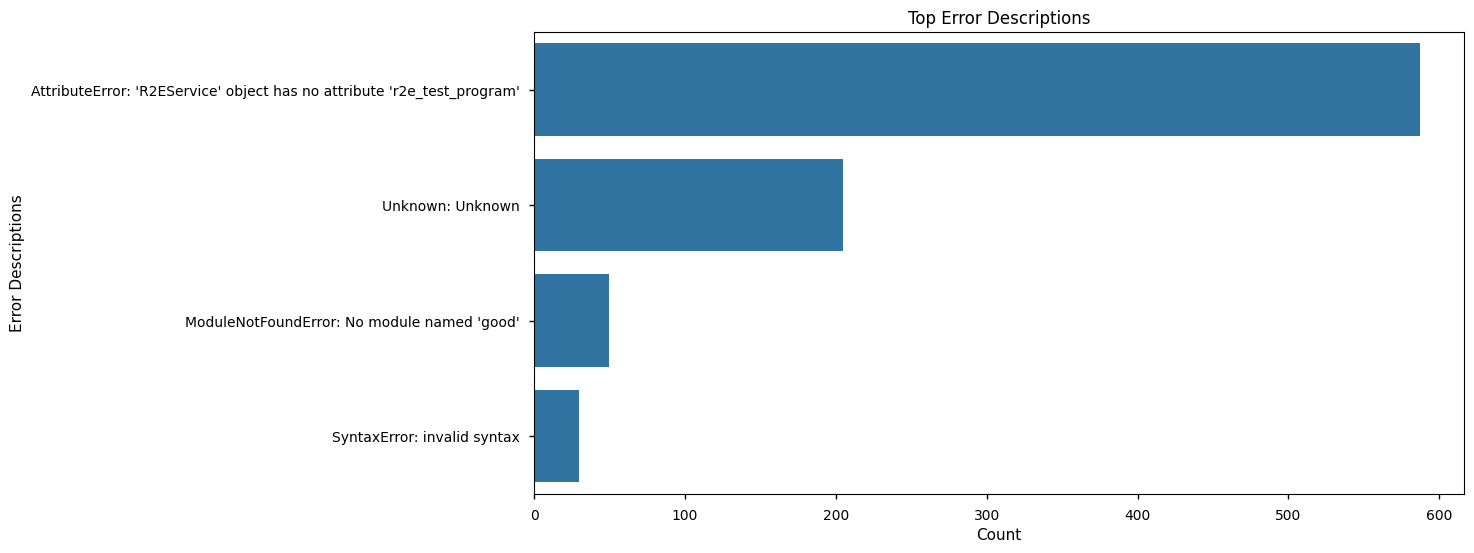

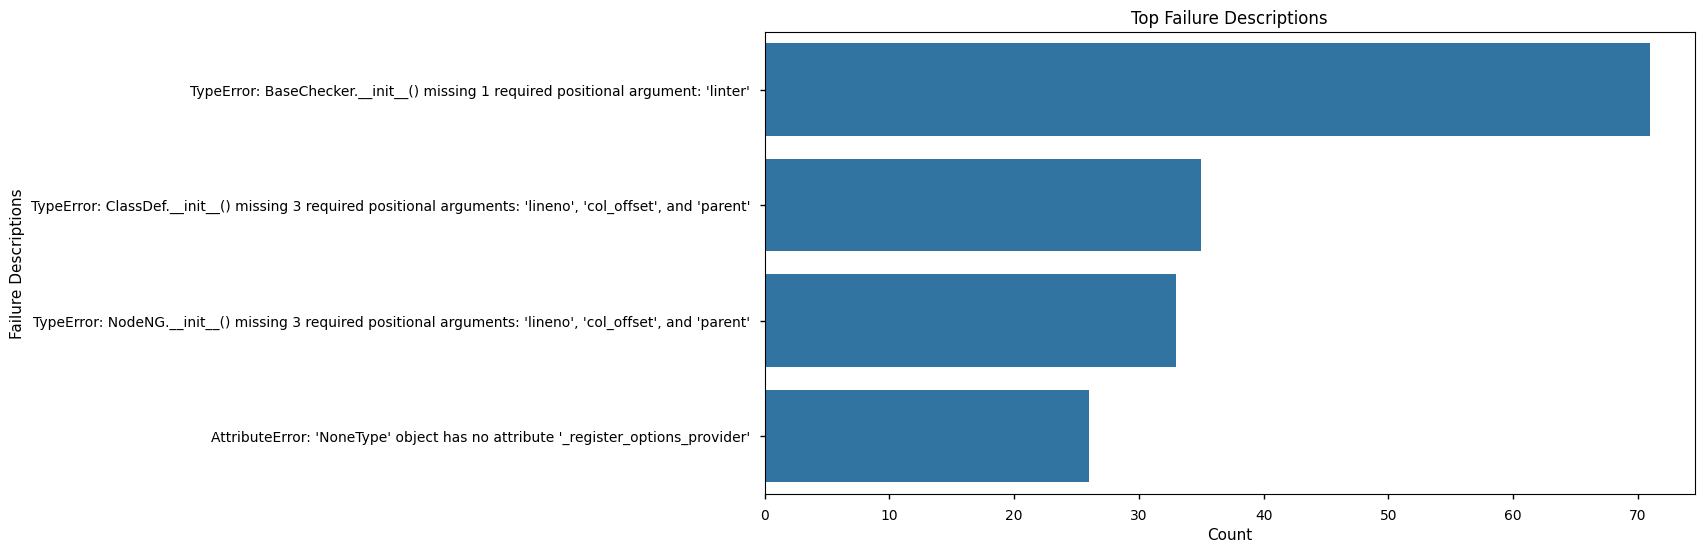

In [19]:
plot_top(analysis_results['error_descriptions'], 'Error Descriptions', n=4)
plot_top(analysis_results['failure_descriptions'], 'Failure Descriptions', n=4)

# Analyze Performance Tests

In [20]:
success_data = [i for i in data if get_test_status(i) == 'success']

In [21]:
import numpy as np
from tqdm import tqdm


def extract_profile_from_stdout(stdout: str) -> List[float]:
    time_pattern = r'([\d.]+(?:e[-+]?\d+)?)\s*(seconds|s|sec)(?!\w)'
    extracted_times = re.findall(time_pattern, stdout)
    
    return [float(time[0]) for time in extracted_times]


def get_stats(fid: str):
    return next((stat for stat in stats if stat['id'] == fid), None)


def get_output(fid: str):
    return next((item for item in success_data if item.get("function_id", item.get("method_id", {})).get("identifier", "") == fid), None)


def get_performance_stats(data: List[Dict[str, Any]]) -> List[Dict[str, Any]]:
    stats = []
    
    for item in tqdm(data, desc="Processing performance data"):
        isprofiled = True
        fid = item.get("function_id", item.get("method_id", {})).get("identifier", "")
        test_history = item.get('test_history', {}).get('history', [{}])[0]
        exec_stats = test_history.get('exec_stats', {})
        instrumenter_logs = exec_stats.get('instrumenter_logs', {})
        durations = [profile.get('duration', 0) for profile in instrumenter_logs]
        
        if durations == []:
            temp = extract_profile_from_stdout(exec_stats.get('output', ''))
            if temp:
                isprofiled = False
                durations = temp
            else:
                continue
        
        stats.append({
            "id": fid,
            "samples": durations,
            "mean": np.mean(durations),
            "median": np.median(durations),
            "std": np.std(durations),
            "min": np.min(durations),
            "max": np.max(durations),
            "q1": np.percentile(durations, 25),
            "q3": np.percentile(durations, 75),
            "profiled": isprofiled
        })
    
    return stats 

In [22]:
stats = get_performance_stats(success_data)  

Processing performance data: 100%|██████████| 581/581 [00:00<00:00, 1271.18it/s]


In [23]:
def plot_function_comparison(stats: List[Dict[str, Any]], k=10):
    sorted_stats = sorted(stats, key=lambda x: x['mean'], reverse=True)
    top_k = sorted_stats[:k]
    
    # print it out
    print(f"Top {k} Functions by Mean Execution Time:")
    for stat in top_k:
        print(f"Function ID: {stat['id']}")
        print(f"Mean Duration: {stat['mean']:.6f}")
        print(f"Profiled: {stat['profiled']}")
        print()
        
    
    plt.figure(figsize=(12, 6))
    bars = plt.bar(
        [stat['id'] for stat in top_k], 
        [stat['mean'] for stat in top_k], 
        color=['blue' if stat['profiled'] else 'orange' for stat in top_k]
    )
    
    plt.title(f'Top {k} Functions by Mean Execution Time')
    plt.xlabel('Function ID')
    plt.ylabel('Mean Duration (seconds)')
    plt.xticks(rotation=45, ha='right')
    plt.legend([bars[0], bars[1]], ['Profiled', 'Not Profiled'])
    plt.tight_layout()
    plt.show()

def analyze_performance(stats: List[Dict[str, Any]], top_k: int = 10):
    plot_function_comparison(stats, top_k)
    
    # Additional insights
    slowest_function = max(stats, key=lambda x: x['mean'])
    most_variable = max(stats, key=lambda x: x['std'])
    
    print("\nAdditional Insights:")
    print(f"Number of functions analyzed: {len(stats)}")
    print(f"Slowest function on average: {slowest_function['id']} (Mean: {slowest_function['mean']:.6f})")
    print(f"Most variable function: {most_variable['id']} (Std Dev: {most_variable['std']:.6f})")
    
    # Calculate overall statistics
    all_means = [stat['mean'] for stat in stats]
    print(f"\nOverall Statistics:")
    print(f"Mean of mean durations: {np.mean(all_means):.6f}")
    print(f"Median of mean durations: {np.median(all_means):.6f}")
    print(f"Standard deviation of mean durations: {np.std(all_means):.6f}")

Top 50 Functions by Mean Execution Time:
Function ID: pylint.graph.get_cycles
Mean Duration: 0.259354
Profiled: True

Function ID: doc.data.messages.u.unspecified-encoding.bad.foo
Mean Duration: 0.252602
Profiled: True

Function ID: doc.data.messages.u.unspecified-encoding.good.foo
Mean Duration: 0.244796
Profiled: True

Function ID: pylint.pyreverse.inspector.project_from_files
Mean Duration: 0.170857
Profiled: True

Function ID: pylint.lint.utils.prepare_crash_report
Mean Duration: 0.122123
Profiled: True

Function ID: doc.data.messages.r.redefined-outer-name.good.count_it
Mean Duration: 0.047401
Profiled: True

Function ID: pylint.pyreverse.utils.check_if_graphviz_supports_format
Mean Duration: 0.044155
Profiled: True

Function ID: doc.data.messages.l.locally-disabled.bad.wizard_spells
Mean Duration: 0.043807
Profiled: True

Function ID: pylint.extensions._check_docs_utils._annotations_list
Mean Duration: 0.041822
Profiled: True

Function ID: pylint.checkers.typecheck._similar_names

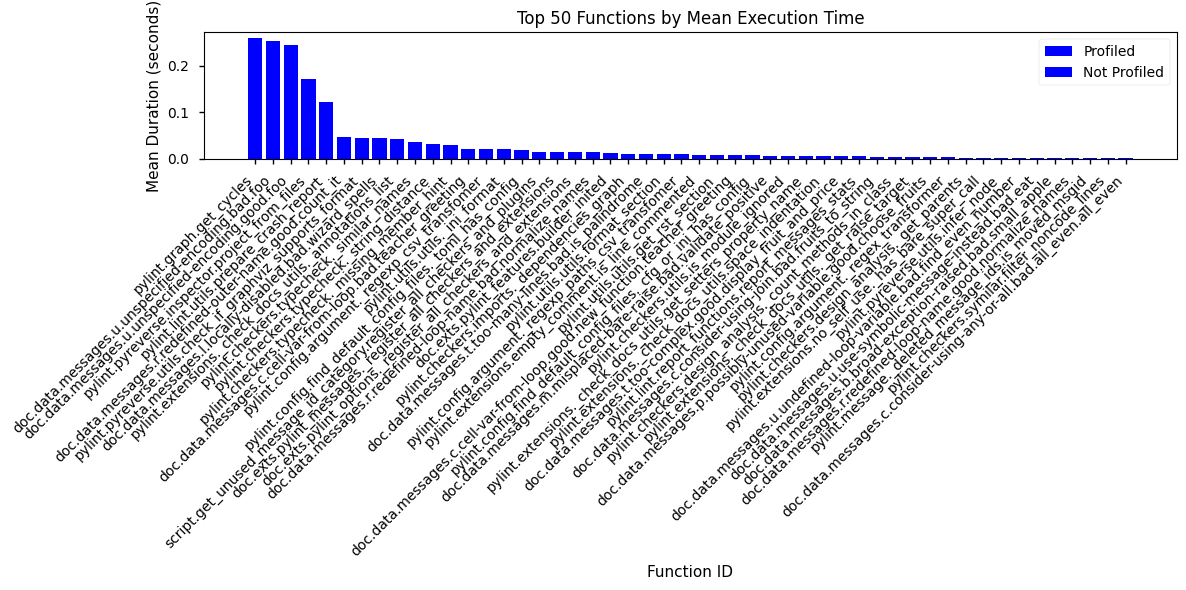


Additional Insights:
Number of functions analyzed: 253
Slowest function on average: pylint.graph.get_cycles (Mean: 0.259354)
Most variable function: pylint.graph.get_cycles (Std Dev: 0.517756)

Overall Statistics:
Mean of mean durations: 0.006455
Median of mean durations: 0.000032
Standard deviation of mean durations: 0.030738


In [24]:
analyze_performance(stats, top_k=50)

# Optimization Potential Analysis